# Fine-Tune YOLOv11 with Land Masking for Boat Detection

**Problem:** The model is detecting objects on land (cars, people, umbrellas) as boats.

**Solution:** Mask out the land area during both training and inference:
1. Apply a triangle mask to black out land regions in training images
2. Remove any annotations that fall in the masked (land) area
3. Retrain the model on water-only data
4. Apply the same mask during inference

This approach teaches the model to focus exclusively on the water region.

---
## Step 1: Install Dependencies

In [1]:
!pip install -q opencv-python-headless
!pip install -q ultralytics
!pip install -q sahi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.7 MB/s eta 0:00:00


---
## Step 2: Import Libraries

In [2]:
import os
import json
import shutil
import random
from pathlib import Path
from copy import deepcopy

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO

print("Imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports successful!
PyTorch version: 2.9.0+cpu
CUDA available: False


---
## Step 3: Configure Paths

In [13]:
#Setting file paths
SOURCE_IMAGE_FOLDER = "/content/Jupiter_Inlet"
SOURCE_COCO_JSON = "/content/_annotations.coco.json"

# Output folders
MASKED_DATASET_PATH = "/content/Jupiter_Inlet/masked_dataset"
YOLO_DATASET_PATH = "/content/Jupiter_Inlet/yolo_masked_dataset"
TRAINING_OUTPUT_PATH = "/content/Jupiter_Inlet/yolo_training/jupiter_boats_masked_v1"

# Training configuration
TRAIN_SPLIT = 0.8  # 80% training, 20% validation
RANDOM_SEED = 42

print(f"Source images: {SOURCE_IMAGE_FOLDER}")
print(f"Source annotations: {SOURCE_COCO_JSON}")
print(f"Masked dataset: {MASKED_DATASET_PATH}")
print(f"YOLO dataset: {YOLO_DATASET_PATH}")

Source images: /content/Jupiter_Inlet
Source annotations: /content/_annotations.coco.json
Masked dataset: /content/Jupiter_Inlet/masked_dataset
YOLO dataset: /content/Jupiter_Inlet/yolo_masked_dataset


---
## Step 4: Define Water Polygon Mask

This is a right traingle mask with the right angle at the bottom LEFT corner.
- The hypotenuse runs diagonally from top-left (0,0) to a point on the bottom edge
- Everything below/left of the hypotenuse (land) is masked out
- Everything above/right of the hypotenuse (water) is kept

In [14]:
#Defining where the hypotenuse is
HYPOTENUSE_BOTTOM_X = 2500

#note to self..... this appears to move among images????

EXPECTED_WIDTH = 4352
EXPECTED_HEIGHT = 3264

# Water polygon
WATER_POLYGON = [
    (0, 0),                          # Top-left corner
    (EXPECTED_WIDTH, 0),             # Top-right corner
    (EXPECTED_WIDTH, EXPECTED_HEIGHT),  # Bottom-right corner
    (HYPOTENUSE_BOTTOM_X, EXPECTED_HEIGHT),  # Where hypotenuse meets bottom
    (0, 0),                          # Back to top-left (closes the polygon)
]

print(f"Water polygon defined with {len(WATER_POLYGON)} vertices")
print(f"Hypotenuse runs from (0, 0) to ({HYPOTENUSE_BOTTOM_X}, {EXPECTED_HEIGHT})")
print(f"Expected image dimensions: {EXPECTED_WIDTH} x {EXPECTED_HEIGHT}")

Water polygon defined with 5 vertices
Hypotenuse runs from (0, 0) to (2500, 3264)
Expected image dimensions: 4352 x 3264


---
## Step 5: Masking Utility Functions

In [15]:
def create_water_mask(width, height, polygon_points):
    """
    Create a binary mask from polygon points.

    Args:
        width: Image width
        height: Image height
        polygon_points: List of (x, y) tuples defining water boundary

    Returns:
        mask: Binary numpy array (255=water/keep, 0=land/mask out)
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    polygon = np.array(polygon_points, dtype=np.int32)
    cv2.fillPoly(mask, [polygon], 255)
    return mask


def scale_polygon(polygon, orig_width, orig_height, new_width, new_height):
    """
    Scale polygon coordinates to match different image dimensions.
    """
    scale_x = new_width / orig_width
    scale_y = new_height / orig_height
    return [(int(x * scale_x), int(y * scale_y)) for x, y in polygon]


def get_scaled_polygon(width, height):
    """
    Get the water polygon scaled to the given image dimensions.
    """
    if width != EXPECTED_WIDTH or height != EXPECTED_HEIGHT:
        return scale_polygon(WATER_POLYGON, EXPECTED_WIDTH, EXPECTED_HEIGHT, width, height)
    return WATER_POLYGON


def apply_mask_to_image(image, mask):
    """
    Apply binary mask to image, blacking out areas where mask is 0.

    Args:
        image: BGR image (numpy array)
        mask: Binary mask (255=keep, 0=black out)

    Returns:
        Masked image
    """
    if len(mask.shape) == 3:
        mask = mask[:, :, 0]
    return cv2.bitwise_and(image, image, mask=mask)


def is_bbox_in_water(bbox, mask, min_overlap=0.5):
    """
    Check if a bounding box is predominantly in the water region.

    Args:
        bbox: (x, y, width, height) in pixels (COCO format)
        mask: Binary mask (255=water)
        min_overlap: Minimum fraction of bbox that must be in water

    Returns:
        True if bbox is in water, False otherwise
    """
    x, y, w, h = [int(v) for v in bbox]

    # Clamp to image bounds
    x = max(0, x)
    y = max(0, y)
    x2 = min(mask.shape[1], x + w)
    y2 = min(mask.shape[0], y + h)

    if x2 <= x or y2 <= y:
        return False

    # Extract mask region under bbox
    bbox_mask = mask[y:y2, x:x2]

    # Calculate overlap
    water_pixels = np.sum(bbox_mask > 0)
    total_pixels = bbox_mask.size

    if total_pixels == 0:
        return False

    return (water_pixels / total_pixels) >= min_overlap


print("Masking utility functions defined.")

Masking utility functions defined.


---
## Step 6: Visualize the Mask

Sample image: a010730g_jpg.rf.6f26d2602c226a64932d98996353ffc1.jpg
Image dimensions: 4352 x 3264


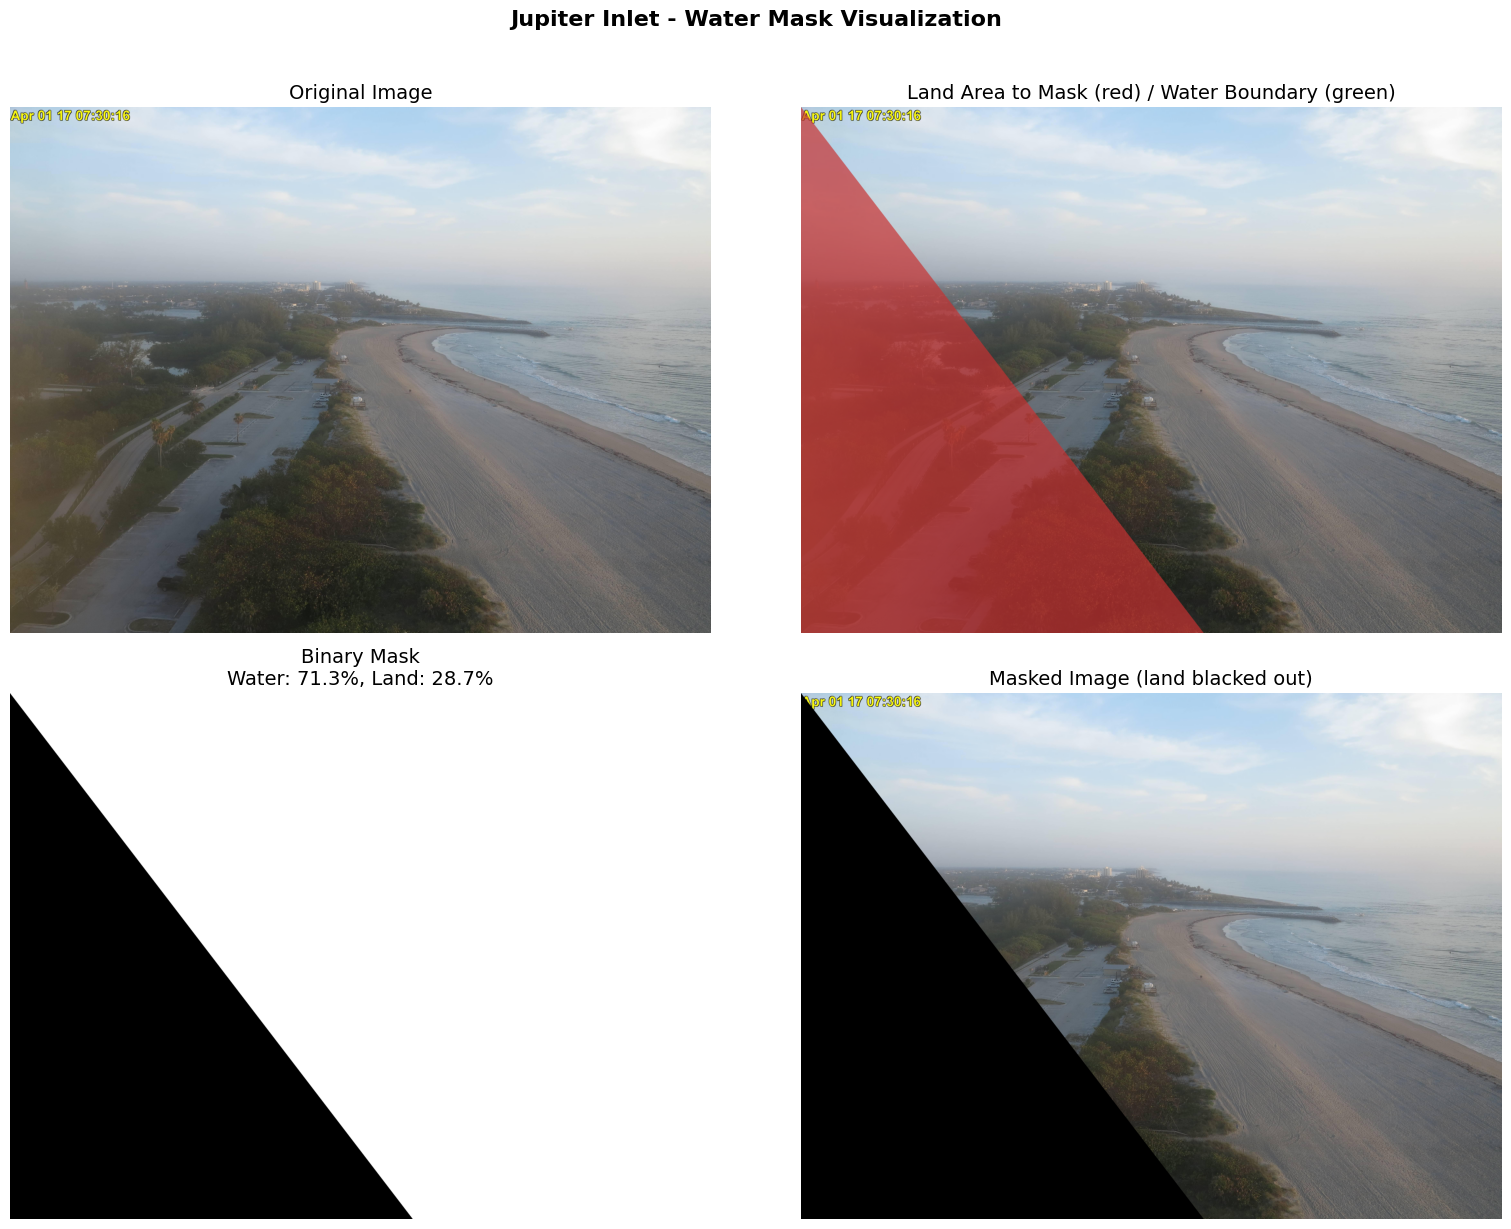


Water coverage: 71.3%
Land masked: 28.7%


In [16]:
# Find a sample image
image_files = sorted([
    f for f in os.listdir(SOURCE_IMAGE_FOLDER)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

if not image_files:
    raise FileNotFoundError(f"No images found in {SOURCE_IMAGE_FOLDER}")

# Load sample image
sample_image_path = os.path.join(SOURCE_IMAGE_FOLDER, image_files[0])
sample_image = cv2.imread(sample_image_path)
h, w = sample_image.shape[:2]

print(f"Sample image: {image_files[0]}")
print(f"Image dimensions: {w} x {h}")

# Get scaled polygon and create mask
scaled_polygon = get_scaled_polygon(w, h)
mask = create_water_mask(w, h, scaled_polygon)

# Apply mask to sample image
masked_image = apply_mask_to_image(sample_image, mask)

# Create visualization with overlay
sample_rgb = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
overlay_img = sample_rgb.copy().astype(np.float32)
land_mask = cv2.bitwise_not(mask)
overlay_img[land_mask > 0] = overlay_img[land_mask > 0] * 0.3 + np.array([200, 50, 50]) * 0.7

# Draw polygon boundary
pts = np.array(scaled_polygon, dtype=np.int32).reshape((-1, 1, 2))
cv2.polylines(overlay_img.astype(np.uint8), [pts], True, (0, 255, 0), 4)

# Calculate stats
water_pct = np.sum(mask > 0) / mask.size * 100

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(sample_rgb)
axes[0, 0].set_title('Original Image', fontsize=14)
axes[0, 0].axis('off')

axes[0, 1].imshow(overlay_img.astype(np.uint8))
axes[0, 1].set_title('Land Area to Mask (red) / Water Boundary (green)', fontsize=14)
axes[0, 1].axis('off')

axes[1, 0].imshow(mask, cmap='gray')
axes[1, 0].set_title(f'Binary Mask\nWater: {water_pct:.1f}%, Land: {100-water_pct:.1f}%', fontsize=14)
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Masked Image (land blacked out)', fontsize=14)
axes[1, 1].axis('off')

plt.suptitle('Jupiter Inlet - Water Mask Visualization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nWater coverage: {water_pct:.1f}%")
print(f"Land masked: {100 - water_pct:.1f}%")

---
## Step 7: Process COCO Annotations and Create Masked Dataset

This step:
1. Loads original images and annotations
2. Applies the mask to each image
3. Filters out annotations that fall in the masked (land) area
4. Saves the masked images and filtered annotations

In [17]:
def process_coco_with_mask(coco_json_path, image_folder, output_folder, min_overlap=0.5):
    """
    Process COCO dataset by masking images and filtering annotations.

    Args:
        coco_json_path: Path to COCO annotations JSON
        image_folder: Folder containing images
        output_folder: Where to save masked images and new annotations
        min_overlap: Minimum overlap with water for annotation to be kept

    Returns:
        Stats dictionary
    """
    # Load COCO annotations
    with open(coco_json_path) as f:
        coco_data = json.load(f)

    # Create output directories
    os.makedirs(os.path.join(output_folder, 'images'), exist_ok=True)

    # Build ID -> image mapping
    id_to_image = {img['id']: img for img in coco_data['images']}

    # Build image_id -> annotations mapping
    id_to_annotations = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in id_to_annotations:
            id_to_annotations[img_id] = []
        id_to_annotations[img_id].append(ann)

    # Track statistics
    stats = {
        'images_processed': 0,
        'annotations_kept': 0,
        'annotations_filtered': 0,
    }

    # New annotations list
    new_annotations = []
    new_annotation_id = 1

    print(f"Processing {len(coco_data['images'])} images...")

    for img_info in coco_data['images']:
        img_id = img_info['id']
        img_filename = img_info['file_name']

        # Load image
        img_path = os.path.join(image_folder, img_filename)
        if not os.path.exists(img_path):
            print(f"  Warning: Image not found: {img_filename}")
            continue

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        # Get scaled polygon and create mask
        scaled_poly = get_scaled_polygon(w, h)
        mask = create_water_mask(w, h, scaled_poly)

        # Apply mask to image
        masked_img = apply_mask_to_image(img, mask)

        # Save masked image
        output_img_path = os.path.join(output_folder, 'images', img_filename)
        cv2.imwrite(output_img_path, masked_img)

        # Process annotations for this image
        annotations = id_to_annotations.get(img_id, [])

        for ann in annotations:
            bbox = ann['bbox']  # COCO format: [x, y, width, height]

            # Check if annotation is in water
            if is_bbox_in_water(bbox, mask, min_overlap):
                # Keep this annotation with new ID
                new_ann = deepcopy(ann)
                new_ann['id'] = new_annotation_id
                new_annotations.append(new_ann)
                new_annotation_id += 1
                stats['annotations_kept'] += 1
            else:
                stats['annotations_filtered'] += 1

        stats['images_processed'] += 1

        if stats['images_processed'] % 50 == 0:
            print(f"  Processed {stats['images_processed']} images...")

    # Create new COCO JSON with filtered annotations
    new_coco = {
        'images': coco_data['images'],
        'categories': coco_data['categories'],
        'annotations': new_annotations
    }

    # Save new annotations
    output_json_path = os.path.join(output_folder, '_annotations.coco.json')
    with open(output_json_path, 'w') as f:
        json.dump(new_coco, f)

    print(f"\n" + "="*50)
    print("Processing complete!")
    print(f"="*50)
    print(f"Images processed: {stats['images_processed']}")
    print(f"Annotations kept (in water): {stats['annotations_kept']}")
    print(f"Annotations filtered (on land): {stats['annotations_filtered']}")
    print(f"\nMasked images saved to: {os.path.join(output_folder, 'images')}")
    print(f"New annotations saved to: {output_json_path}")

    return stats

In [18]:
# Process the dataset
stats = process_coco_with_mask(
    coco_json_path=SOURCE_COCO_JSON,
    image_folder=SOURCE_IMAGE_FOLDER,
    output_folder=MASKED_DATASET_PATH,
    min_overlap=0.5  # Annotation must be 50% in water to be kept
)

Processing 366 images...
  Processed 50 images...
  Processed 100 images...
  Processed 150 images...
  Processed 200 images...
  Processed 250 images...
  Processed 300 images...
  Processed 350 images...

Processing complete!
Images processed: 366
Annotations kept (in water): 1193
Annotations filtered (on land): 6

Masked images saved to: /content/Jupiter_Inlet/masked_dataset/images
New annotations saved to: /content/Jupiter_Inlet/masked_dataset/_annotations.coco.json


---
## Step 8: Visualize Masked Images with Annotations

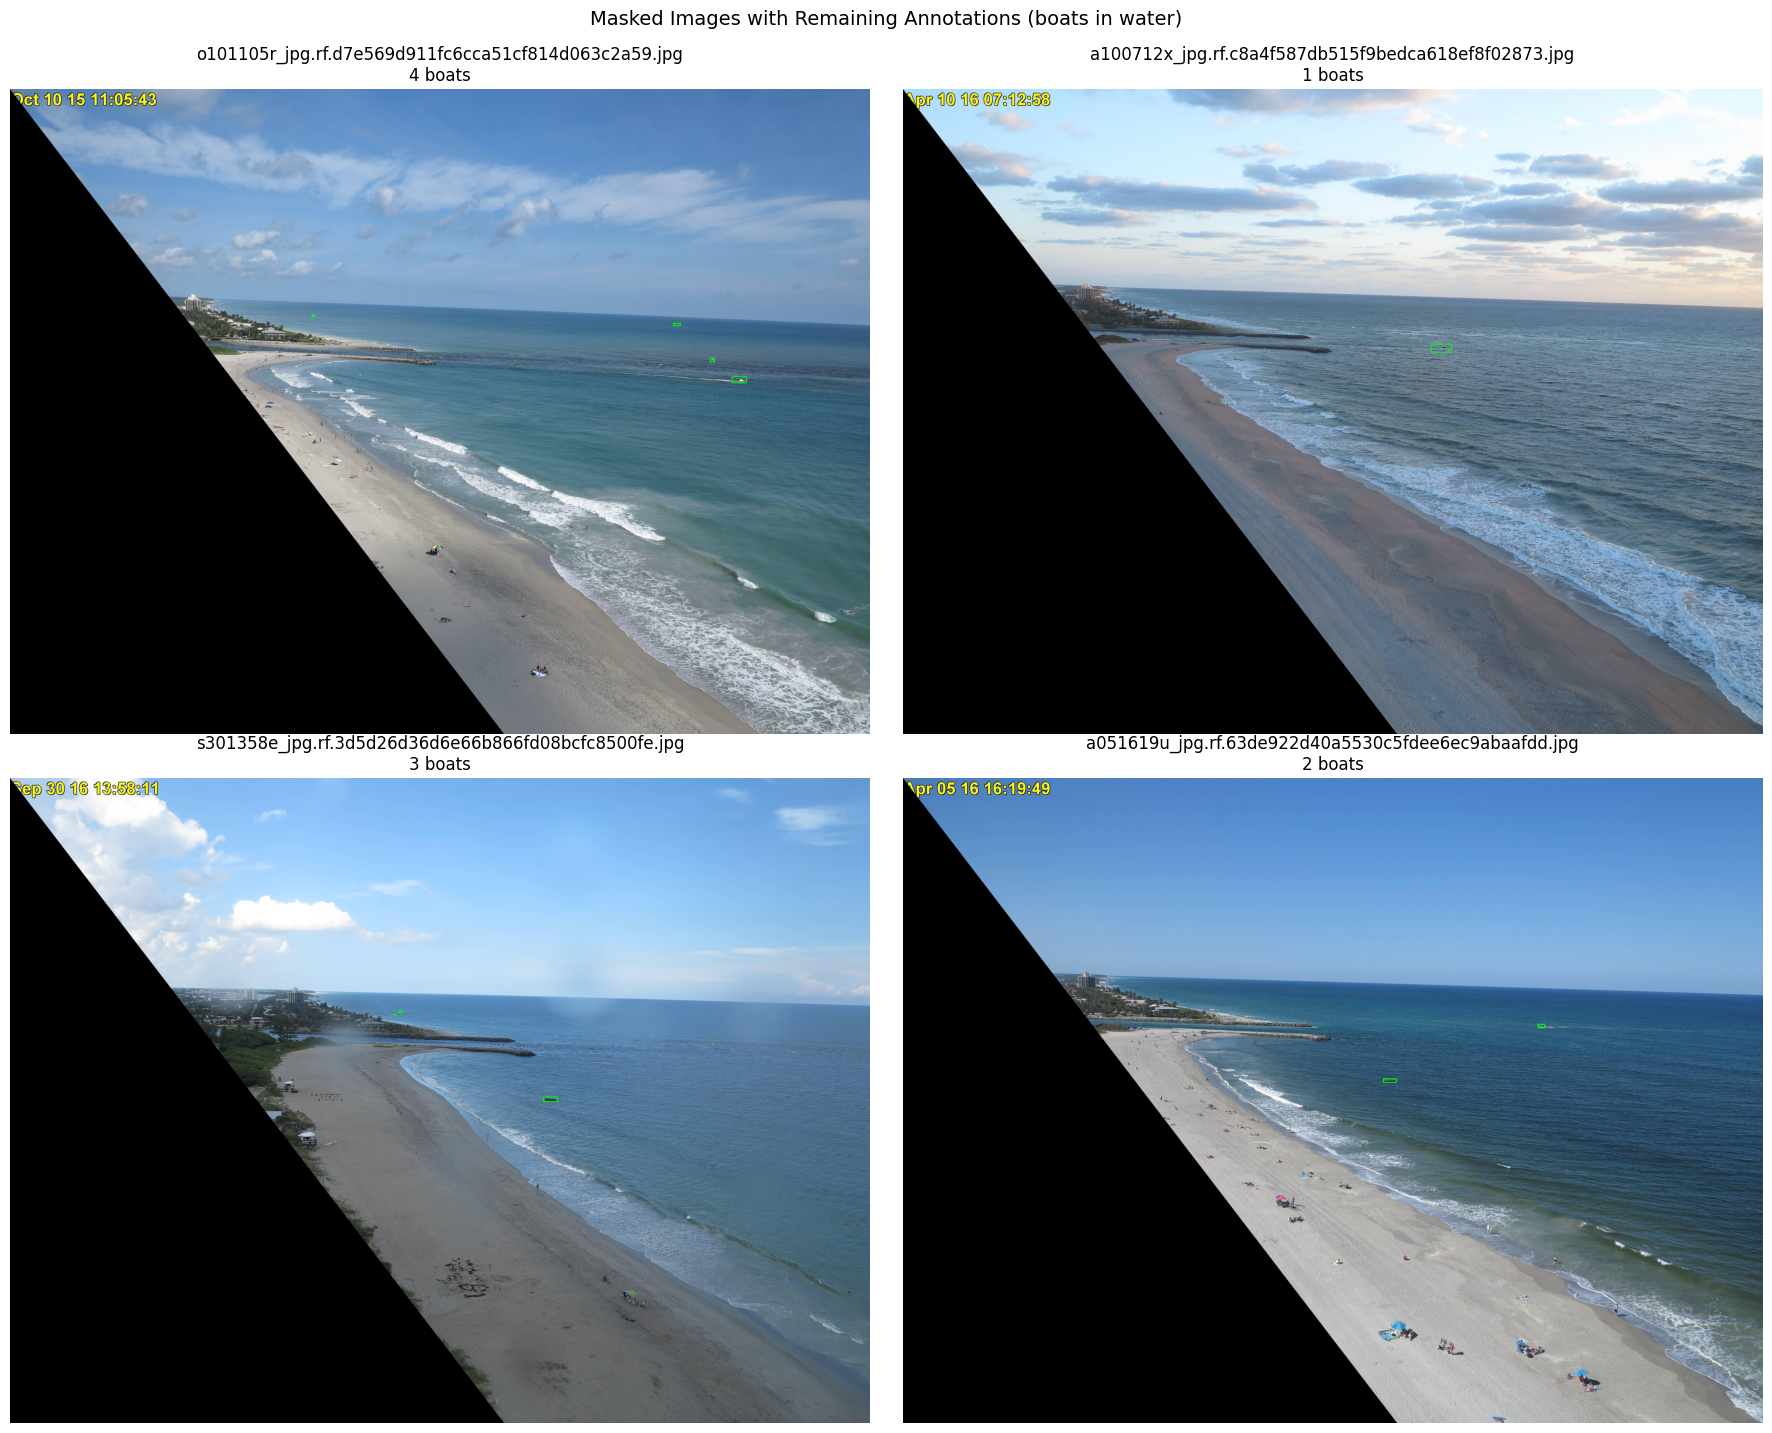

In [19]:
def visualize_masked_annotations(image_folder, coco_json_path, num_samples=4):
    """
    Visualize masked images with their remaining annotations.
    """
    # Load annotations
    with open(coco_json_path) as f:
        coco_data = json.load(f)

    # Build mappings
    id_to_image = {img['id']: img for img in coco_data['images']}
    id_to_annotations = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in id_to_annotations:
            id_to_annotations[img_id] = []
        id_to_annotations[img_id].append(ann)

    # Find images with annotations
    images_with_annotations = [
        img_id for img_id in id_to_annotations
        if len(id_to_annotations[img_id]) > 0
    ]

    if not images_with_annotations:
        print("No images with annotations found!")
        return

    # Sample images
    sample_ids = random.sample(
        images_with_annotations,
        min(num_samples, len(images_with_annotations))
    )

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()

    for i, img_id in enumerate(sample_ids):
        if i >= len(axes):
            break

        img_info = id_to_image[img_id]
        img_path = os.path.join(image_folder, img_info['file_name'])

        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw annotations
        annotations = id_to_annotations.get(img_id, [])
        for ann in annotations:
            x, y, w, h = [int(v) for v in ann['bbox']]
            cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 3)

        axes[i].imshow(img_rgb)
        axes[i].set_title(f"{img_info['file_name']}\n{len(annotations)} boats")
        axes[i].axis('off')

    plt.tight_layout()
    plt.suptitle('Masked Images with Remaining Annotations (boats in water)',
                 y=1.02, fontsize=14)
    plt.show()


# Visualize
visualize_masked_annotations(
    os.path.join(MASKED_DATASET_PATH, 'images'),
    os.path.join(MASKED_DATASET_PATH, '_annotations.coco.json')
)

---
## Step 9: Convert Masked COCO to YOLO Format

In [20]:
def coco_to_yolo_format(coco_json_path, image_folder, output_folder,
                        train_split=0.8, seed=42):
    """
    Convert COCO annotations to YOLO format and split into train/val.
    """
    # Load COCO annotations
    with open(coco_json_path) as f:
        coco_data = json.load(f)

    # Create output directories
    for split in ['train', 'val']:
        os.makedirs(os.path.join(output_folder, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(output_folder, 'labels', split), exist_ok=True)

    # Build mappings
    id_to_image = {img['id']: img for img in coco_data['images']}
    id_to_annotations = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in id_to_annotations:
            id_to_annotations[img_id] = []
        id_to_annotations[img_id].append(ann)

    # Create category mapping (COCO category_id -> YOLO class_id starting at 0)
    categories = sorted(coco_data['categories'], key=lambda x: x['id'])
    category_mapping = {cat['id']: i for i, cat in enumerate(categories)}
    class_names = [cat['name'] for cat in categories]

    print(f"Categories: {class_names}")
    print(f"Category mapping: {category_mapping}")

    # Shuffle and split images
    image_ids = list(id_to_image.keys())
    random.seed(seed)
    random.shuffle(image_ids)

    split_idx = int(len(image_ids) * train_split)
    train_ids = set(image_ids[:split_idx])
    val_ids = set(image_ids[split_idx:])

    print(f"\nTotal images: {len(image_ids)}")
    print(f"Training images: {len(train_ids)}")
    print(f"Validation images: {len(val_ids)}")

    # Process each image
    stats = {'train': 0, 'val': 0, 'annotations': 0}

    for img_id in image_ids:
        img_info = id_to_image[img_id]
        img_filename = img_info['file_name']
        img_width = img_info['width']
        img_height = img_info['height']

        # Determine split
        split = 'train' if img_id in train_ids else 'val'

        # Source and destination paths
        src_img = os.path.join(image_folder, img_filename)
        dst_img = os.path.join(output_folder, 'images', split, img_filename)

        if not os.path.exists(src_img):
            continue

        # Copy image
        shutil.copy2(src_img, dst_img)

        # Convert annotations to YOLO format
        annotations = id_to_annotations.get(img_id, [])
        yolo_lines = []

        for ann in annotations:
            # COCO bbox: [x, y, width, height] (top-left corner)
            x, y, w, h = ann['bbox']

            # Convert to YOLO format: [class_id, center_x, center_y, width, height] normalized
            center_x = (x + w / 2) / img_width
            center_y = (y + h / 2) / img_height
            norm_w = w / img_width
            norm_h = h / img_height

            # Get YOLO class ID
            class_id = category_mapping.get(ann['category_id'], 0)

            yolo_lines.append(f"{class_id} {center_x:.6f} {center_y:.6f} {norm_w:.6f} {norm_h:.6f}")
            stats['annotations'] += 1

        # Save YOLO label file
        label_filename = os.path.splitext(img_filename)[0] + '.txt'
        label_path = os.path.join(output_folder, 'labels', split, label_filename)

        with open(label_path, 'w') as f:
            f.write('\n'.join(yolo_lines))

        stats[split] += 1

    # Create dataset.yaml
    yaml_content = f"""# Jupiter Inlet Boat Detection Dataset (Masked)
# Auto-generated

path: {output_folder}
train: images/train
val: images/val

# Number of classes
nc: {len(class_names)}

# Class names
names: {class_names}
"""

    yaml_path = os.path.join(output_folder, 'dataset.yaml')
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    print(f"\n" + "="*50)
    print("YOLO dataset created!")
    print(f"="*50)
    print(f"Training images: {stats['train']}")
    print(f"Validation images: {stats['val']}")
    print(f"Total annotations: {stats['annotations']}")
    print(f"\nDataset YAML: {yaml_path}")

    return yaml_path, class_names

In [21]:
# Convert masked dataset to YOLO format
dataset_yaml, class_names = coco_to_yolo_format(
    coco_json_path=os.path.join(MASKED_DATASET_PATH, '_annotations.coco.json'),
    image_folder=os.path.join(MASKED_DATASET_PATH, 'images'),
    output_folder=YOLO_DATASET_PATH,
    train_split=TRAIN_SPLIT,
    seed=RANDOM_SEED
)

Categories: ['Boat', 'Boat']
Category mapping: {0: 0, 1: 1}

Total images: 366
Training images: 292
Validation images: 74

YOLO dataset created!
Training images: 292
Validation images: 74
Total annotations: 1193

Dataset YAML: /content/Jupiter_Inlet/yolo_masked_dataset/dataset.yaml


---
## Step 10: Visualize YOLO Training Data

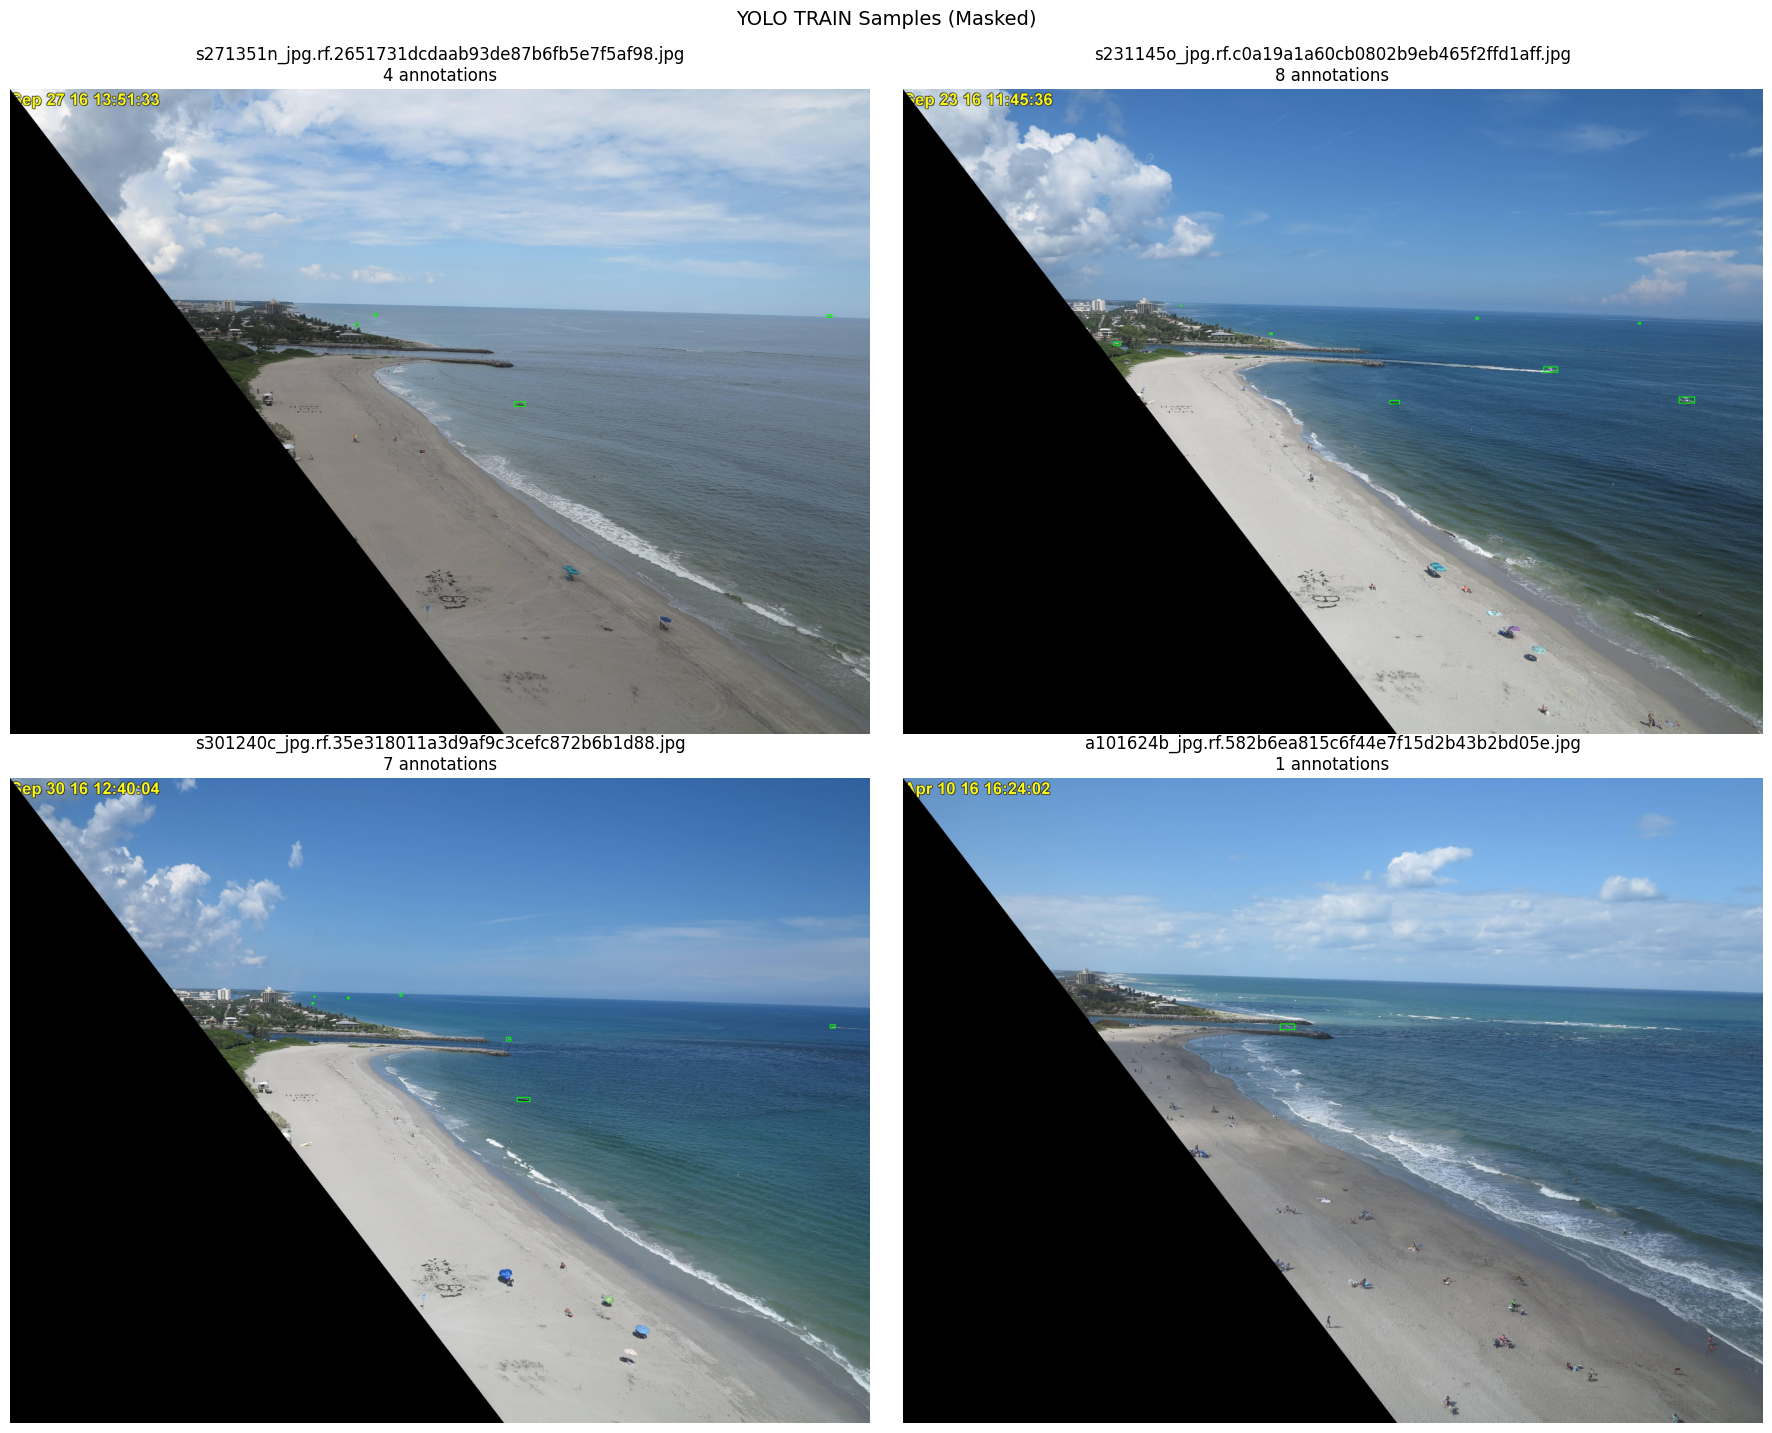

In [22]:
def visualize_yolo_samples(dataset_path, split='train', num_samples=4):
    """
    Visualize YOLO-format training samples.
    """
    images_dir = os.path.join(dataset_path, 'images', split)
    labels_dir = os.path.join(dataset_path, 'labels', split)

    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))]
    sample_files = random.sample(image_files, min(num_samples, len(image_files)))

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()

    for i, img_file in enumerate(sample_files):
        if i >= len(axes):
            break

        # Load image
        img_path = os.path.join(images_dir, img_file)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Load labels
        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_file)

        num_boxes = 0
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = map(float, parts)

                        # Convert to pixel coordinates
                        x1 = int((cx - bw/2) * w)
                        y1 = int((cy - bh/2) * h)
                        x2 = int((cx + bw/2) * w)
                        y2 = int((cy + bh/2) * h)

                        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 3)
                        num_boxes += 1

        axes[i].imshow(img_rgb)
        axes[i].set_title(f"{img_file}\n{num_boxes} annotations")
        axes[i].axis('off')

    plt.tight_layout()
    plt.suptitle(f'YOLO {split.upper()} Samples (Masked)', y=1.02, fontsize=14)
    plt.show()


# Visualize training samples
visualize_yolo_samples(YOLO_DATASET_PATH, split='train')

---
## Step 11: Train YOLOv11 on Masked Data

In [23]:
# Load pre-trained YOLOv11m model
model = YOLO('yolo11m.pt')

print("Model loaded successfully!")
print(f"Dataset: {dataset_yaml}")

Model loaded successfully!
Dataset: /content/Jupiter_Inlet/yolo_masked_dataset/dataset.yaml


In [ ]:
# Train the model
results = model.train(
    data=dataset_yaml,
    epochs=100,
    imgsz=1280,
    batch=5,
    project=TRAINING_OUTPUT_PATH,
    name='',
    exist_ok=True,

    # Data augmentation
    #probably needs to be changed
    augment=True,
    hsv_h=0.015,        # Hue augmentation
    hsv_s=0.7,          # Saturation augmentation
    hsv_v=0.4,          # Value augmentation
    degrees=10,         # Rotation (Might need to fix this)
    translate=0.1,
    scale=0.5,
    flipud=0.0,         # No vertical flip
    fliplr=0.0,         # No horizontal flip
    mosaic=0.5,         # Reduced mosaic

    # Learning rate
    lr0=0.01,
    lrf=0.01,

    # Optimizer
    optimizer='SGD',
    momentum=0.937,
    weight_decay=0.0005,

    # Early stopping
    patience=20,

    # Verbosity
    verbose=True,
)

Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=5, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Jupiter_Inlet/yolo_masked_dataset/dataset.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, pat

---
## Step 12: Evaluate the Trained Model

In [ ]:
# Get best model path
best_model_path = os.path.join(TRAINING_OUTPUT_PATH, 'weights', 'best.pt')
print(f"Best model: {best_model_path}")

# Load best model
best_model = YOLO(best_model_path)

# Validate on validation set
val_results = best_model.val(data=dataset_yaml)

print("\n" + "="*60)
print("VALIDATION RESULTS")
print("="*60)
print(f"mAP50: {val_results.box.map50:.3f}")
print(f"mAP50-95: {val_results.box.map:.3f}")
print(f"Precision: {val_results.box.mp:.3f}")
print(f"Recall: {val_results.box.mr:.3f}")

---
## Step 13: Test Inference with Masking

In [ ]:
def run_masked_inference(model, image_path, conf_threshold=0.25):
    """
    Run YOLO inference on a masked image.
    """
    # Load image
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    # Get scaled polygon and create mask
    scaled_poly = get_scaled_polygon(w, h)
    mask = create_water_mask(w, h, scaled_poly)

    # Apply mask
    masked_img = apply_mask_to_image(img, mask)

    # Run inference on masked image
    results = model(masked_img, conf=conf_threshold, verbose=False)

    return results[0], masked_img, mask


def visualize_inference(image_path, results, masked_img, original_img=None):
    """
    Visualize inference results.
    """
    boxes = results.boxes

    # Draw on masked image
    display_img = masked_img.copy()

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        conf = box.conf[0].cpu().numpy()

        cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        label = f"boat {conf:.2f}"
        cv2.putText(display_img, label, (x1, y1 - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    if original_img is not None:
        axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original Image')
    else:
        axes[0].imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Masked Image')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Detections: {len(boxes)} boats')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    return len(boxes)

In [ ]:
# Test on validation images
val_images_dir = os.path.join(YOLO_DATASET_PATH, 'images', 'val')
val_images = [os.path.join(val_images_dir, f) for f in os.listdir(val_images_dir)
              if f.endswith(('.jpg', '.png'))][:4]

print(f"Testing on {len(val_images)} validation images...\n")

for img_path in val_images:
    results, masked_img, mask = run_masked_inference(best_model, img_path)

    # Load original for comparison
    original = cv2.imread(img_path)

    num_boats = visualize_inference(img_path, results, masked_img, original)
    print(f"{os.path.basename(img_path)}: {num_boats} boats detected\n")

---
## Step 14: SAHI Integration for Small Object Detection

In [ ]:
from sahi.predict import get_sliced_prediction
from sahi import AutoDetectionModel


def run_masked_sahi_inference(model_path, image_path, slice_height=512, slice_width=512,
                               overlap_ratio=0.3, conf_threshold=0.25):
    """
    Run SAHI inference on a masked image for better small object detection.
    """
    # Load and mask image
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    scaled_poly = get_scaled_polygon(w, h)
    mask = create_water_mask(w, h, scaled_poly)
    masked_img = apply_mask_to_image(img, mask)

    # Save masked image temporarily (SAHI needs file path)
    temp_path = '/tmp/masked_for_sahi.jpg'
    cv2.imwrite(temp_path, masked_img)

    # Create SAHI detection model
    detection_model = AutoDetectionModel.from_pretrained(
        model_type='yolov8',  # Works with YOLOv11
        model_path=model_path,
        confidence_threshold=conf_threshold,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )

    # Run sliced prediction
    result = get_sliced_prediction(
        image=temp_path,
        detection_model=detection_model,
        slice_height=slice_height,
        slice_width=slice_width,
        overlap_height_ratio=overlap_ratio,
        overlap_width_ratio=overlap_ratio,
    )

    return result, masked_img

In [ ]:
# Test SAHI with the fine-tuned model
print("Testing SAHI with masked inference...\n")

for img_path in val_images[:2]:
    result, masked_img = run_masked_sahi_inference(
        best_model_path,
        img_path,
        slice_height=512,
        slice_width=512,
        overlap_ratio=0.3
    )

    # Visualize SAHI results
    result.export_visuals(export_dir='/tmp/sahi_masked_results')
    result_img = cv2.imread('/tmp/sahi_masked_results/prediction_visual.png')

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Masked Input')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'SAHI Detections: {len(result.object_prediction_list)} boats')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"{os.path.basename(img_path)}: {len(result.object_prediction_list)} boats (SAHI)\n")

---
## Step 15: Complete Production Pipeline Class

In [ ]:
class MaskedBoatDetector:
    """
    Complete boat detection pipeline with land masking for Jupiter Inlet.

    Uses a right triangle mask (right angle at bottom-left) to exclude
    land areas (beach, parking lot, vegetation) from detection.
    """

    # Class-level mask configuration
    EXPECTED_WIDTH = 4352
    EXPECTED_HEIGHT = 3264
    HYPOTENUSE_BOTTOM_X = 2200

    def __init__(self, model_path, use_sahi=True, conf_threshold=0.25):
        """
        Initialize the detector.

        Args:
            model_path: Path to trained YOLO model
            use_sahi: Whether to use SAHI for better small object detection
            conf_threshold: Confidence threshold for detections
        """
        self.model_path = model_path
        self.conf_threshold = conf_threshold
        self.use_sahi = use_sahi

        # Define water polygon (right triangle, right angle at bottom-left)
        self.water_polygon = [
            (0, 0),
            (self.EXPECTED_WIDTH, 0),
            (self.EXPECTED_WIDTH, self.EXPECTED_HEIGHT),
            (self.HYPOTENUSE_BOTTOM_X, self.EXPECTED_HEIGHT),
            (0, 0),
        ]

        # Load YOLO model
        self.model = YOLO(model_path)

        # Load SAHI model if requested
        if use_sahi:
            self.sahi_model = AutoDetectionModel.from_pretrained(
                model_type='yolov8',
                model_path=model_path,
                confidence_threshold=conf_threshold,
                device='cuda' if torch.cuda.is_available() else 'cpu'
            )

    def _get_scaled_polygon(self, width, height):
        """Get water polygon scaled to image dimensions."""
        if width != self.EXPECTED_WIDTH or height != self.EXPECTED_HEIGHT:
            scale_x = width / self.EXPECTED_WIDTH
            scale_y = height / self.EXPECTED_HEIGHT
            return [(int(x * scale_x), int(y * scale_y)) for x, y in self.water_polygon]
        return self.water_polygon

    def _create_mask(self, width, height):
        """Create water mask for given image dimensions."""
        mask = np.zeros((height, width), dtype=np.uint8)
        polygon = np.array(self._get_scaled_polygon(width, height), dtype=np.int32)
        cv2.fillPoly(mask, [polygon], 255)
        return mask

    def _apply_mask(self, image, mask):
        """Apply mask to image."""
        return cv2.bitwise_and(image, image, mask=mask)

    def detect(self, image_path, slice_height=512, slice_width=512, overlap_ratio=0.3):
        """
        Detect boats in an image.

        Args:
            image_path: Path to input image
            slice_height: Height of SAHI slices (if use_sahi=True)
            slice_width: Width of SAHI slices
            overlap_ratio: Overlap ratio for SAHI slices

        Returns:
            dict with:
                - 'num_boats': Number of boats detected
                - 'detections': List of detection dicts
                - 'masked_image': The masked input image
                - 'annotated_image': Image with detection boxes drawn
        """
        # Load image
        img = cv2.imread(image_path)
        if img is None:
            raise FileNotFoundError(f"Could not load image: {image_path}")

        h, w = img.shape[:2]

        # Create and apply mask
        mask = self._create_mask(w, h)
        masked_img = self._apply_mask(img, mask)

        detections = []

        if self.use_sahi:
            # Save temp image for SAHI
            temp_path = '/tmp/masked_temp.jpg'
            cv2.imwrite(temp_path, masked_img)

            # Run SAHI
            result = get_sliced_prediction(
                image=temp_path,
                detection_model=self.sahi_model,
                slice_height=slice_height,
                slice_width=slice_width,
                overlap_height_ratio=overlap_ratio,
                overlap_width_ratio=overlap_ratio,
            )

            # Extract detections
            for pred in result.object_prediction_list:
                bbox = pred.bbox.to_xyxy()
                detections.append({
                    'bbox': [bbox[0], bbox[1], bbox[2], bbox[3]],
                    'confidence': pred.score.value,
                    'class': pred.category.name
                })
        else:
            # Run standard YOLO inference
            results = self.model(masked_img, conf=self.conf_threshold, verbose=False)

            for box in results[0].boxes:
                bbox = box.xyxy[0].cpu().numpy()
                detections.append({
                    'bbox': [float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3])],
                    'confidence': float(box.conf[0].cpu().numpy()),
                    'class': 'boat'
                })

        # Create annotated image
        annotated = masked_img.copy()
        for det in detections:
            x1, y1, x2, y2 = [int(v) for v in det['bbox']]
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 3)
            label = f"boat {det['confidence']:.2f}"
            cv2.putText(annotated, label, (x1, y1-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        return {
            'num_boats': len(detections),
            'detections': detections,
            'masked_image': masked_img,
            'annotated_image': annotated
        }

    def detect_and_save(self, image_path, output_path):
        """
        Detect boats and save annotated image.

        Args:
            image_path: Path to input image
            output_path: Path to save annotated image

        Returns:
            Number of boats detected
        """
        result = self.detect(image_path)
        cv2.imwrite(output_path, result['annotated_image'])
        return result['num_boats']


print("MaskedBoatDetector class defined.")

In [ ]:
# Example usage of MaskedBoatDetector
print("Creating MaskedBoatDetector...")

detector = MaskedBoatDetector(
    model_path=best_model_path,
    use_sahi=True,
    conf_threshold=0.25
)

# Test on a validation image
if val_images:
    result = detector.detect(val_images[0])

    print(f"\nDetected {result['num_boats']} boats")
    print(f"Detections: {result['detections']}")

    # Show result
    plt.figure(figsize=(14, 10))
    plt.imshow(cv2.cvtColor(result['annotated_image'], cv2.COLOR_BGR2RGB))
    plt.title(f"Detected: {result['num_boats']} boats")
    plt.axis('off')
    plt.show()

---
## Step 16: Export Model Information

In [ ]:
print("="*70)
print("MASKED BOAT DETECTION MODEL - TRAINING COMPLETE")
print("="*70)
print(f"\nBest model saved at:")
print(f"  {best_model_path}")
print(f"\n" + "-"*70)
print("USAGE EXAMPLE:")
print("-"*70)
print("""
from ultralytics import YOLO
import cv2
import numpy as np

# Load model
model = YOLO('path/to/best.pt')

# Create mask (right triangle, right angle at bottom-left)
def create_mask(width, height, hypotenuse_x=2200, ref_w=4352, ref_h=3264):
    scale_x, scale_y = width / ref_w, height / ref_h
    polygon = np.array([
        [0, 0],
        [width, 0],
        [width, height],
        [int(hypotenuse_x * scale_x), height],
    ], dtype=np.int32)
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [polygon], 255)
    return mask

# Load and mask image
img = cv2.imread('your_image.jpg')
h, w = img.shape[:2]
mask = create_mask(w, h)
masked = cv2.bitwise_and(img, img, mask=mask)

# Run inference
results = model(masked, conf=0.25)
""")
print("="*70)

---
## Summary

**What this notebook does:**

1. **Masks out land regions** using a right triangle (right angle at bottom-left)
2. **Filters annotations** to keep only boats in water areas
3. **Trains YOLOv11** on the masked, water-only dataset
4. **Applies masking during inference** for consistent behavior
5. **Integrates with SAHI** for better small boat detection

**Why this helps:**

- Model never sees land-based objects (cars, people, umbrellas) during training
- No confusion between land objects and boats
- Consistent behavior between training and inference

**Tuning tips:**

- Adjust `HYPOTENUSE_BOTTOM_X` (Step 4) to change where the diagonal meets the bottom edge
- Larger value = more land masked
- Smaller value = less land masked